# E-Commerce Customer Churn — Full Data Science Pipeline

**Dataset:** 5,630 customers × 20 features  
**Target:** `Churn` (binary: 0 = retained, 1 = churned)  
**Goal:** Understand drivers of churn and build predictive models to identify at-risk customers.

---

### Pipeline Outline
1. Setup & Data Loading
2. Data Overview & Quality Assessment
3. Exploratory Data Analysis (EDA) — Business Questions
4. Feature Engineering
5. Preprocessing
6. Model Training (Logistic Regression, Random Forest, XGBoost, SVM)
7. Model Evaluation & Comparison
8. Feature Importance & Business Insights
9. Conclusions & Recommendations

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay, precision_recall_curve,
    average_precision_score
)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("XGBoost not available; will use GradientBoostingClassifier instead.")

# Plotting style
PALETTE = ['#2196F3', '#F44336']
sns.set_theme(style='whitegrid', palette=PALETTE, font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'figure.facecolor': 'white'})

SEED = 42
np.random.seed(SEED)

In [2]:
# ── Load dataset ─────────────────────────────────────────────────────────────
FILE = '/kaggle/input/datasets/ankitverma2010/ecommerce-customer-churn-analysis-and-prediction/E Commerce Dataset.xlsx'

df_raw = pd.read_excel(FILE, sheet_name='E Comm')
df_raw

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5625,55626,0,10.0,Computer,1,30.0,Credit Card,Male,3.0,2,Laptop & Accessory,1,Married,6,0,18.0,1.0,2.0,4.0,150.71
5626,55627,0,13.0,Mobile Phone,1,13.0,Credit Card,Male,3.0,5,Fashion,5,Married,6,0,16.0,1.0,2.0,NaN,224.91
5627,55628,0,1.0,Mobile Phone,1,11.0,Debit Card,Male,3.0,2,Laptop & Accessory,4,Married,3,1,21.0,1.0,2.0,4.0,186.42
5628,55629,0,23.0,Computer,3,9.0,Credit Card,Male,4.0,5,Laptop & Accessory,4,Married,4,0,15.0,2.0,2.0,9.0,178.90


In [7]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   object 
 13  NumberOfAddress   

In [14]:
for col in df_raw.columns:
    if df_raw[col].dtype == 'object':
        display(df_raw[col].value_counts())
        print('-' * 50)

PreferredLoginDevice
Mobile Phone    2765
Computer        1634
Phone           1231
Name: count, dtype: int64

--------------------------------------------------


PreferredPaymentMode
Debit Card          2314
Credit Card         1501
E wallet             614
UPI                  414
COD                  365
CC                   273
Cash on Delivery     149
Name: count, dtype: int64

--------------------------------------------------


Gender
Male      3384
Female    2246
Name: count, dtype: int64

--------------------------------------------------


PreferedOrderCat
Laptop & Accessory    2050
Mobile Phone          1271
Fashion                826
Mobile                 809
Grocery                410
Others                 264
Name: count, dtype: int64

--------------------------------------------------


MaritalStatus
Married     2986
Single      1796
Divorced     848
Name: count, dtype: int64

--------------------------------------------------


### We can observe that several columns has duplicated categories but with different name, like COD and Cash On Delivery in 'PreferredPaymentMode' and Mobile Phone - Phone categories in 'PreferedOrderCat', so we need to standrazie these values to avoid having such noisy data

In [15]:
df_raw.columns = df_raw.columns.str.strip()

# ── Consolidate duplicated category labels ──────────────────────────
# PreferredLoginDevice: 'Phone' is the same as 'Mobile Phone'
df_raw['PreferredLoginDevice'] = df_raw['PreferredLoginDevice'].replace({'Phone': 'Mobile Phone'})

# PreferredPaymentMode: 'COD' == 'Cash on Delivery' | 'CC' == 'Credit Card'
df_raw['PreferredPaymentMode'] = df_raw['PreferredPaymentMode'].replace({
    'COD': 'Cash on Delivery',
    'CC':  'Credit Card'
})

# PreferedOrderCat: 'Mobile Phone' == 'Mobile'
df_raw['PreferedOrderCat'] = df_raw['PreferedOrderCat'].replace({'Mobile': 'Mobile Phone'})

df = df_raw.copy()

# ── Verify ──────────────────────────────────────────────────────────
for col in ['PreferredLoginDevice', 'PreferredPaymentMode', 'PreferedOrderCat']:
    print(f'{col}:\n{df[col].value_counts().to_string()}\n')

print(f'Shape: {df.shape}')
df.head()


PreferredLoginDevice:
PreferredLoginDevice
Mobile Phone    3996
Computer        1634

PreferredPaymentMode:
PreferredPaymentMode
Debit Card          2314
Credit Card         1774
E wallet             614
Cash on Delivery     514
UPI                  414

PreferedOrderCat:
PreferedOrderCat
Mobile Phone          2080
Laptop & Accessory    2050
Fashion                826
Grocery                410
Others                 264

Shape: (5630, 20)


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Mobile Phone,1,8.0,UPI,Male,3.0,4,Mobile Phone,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Mobile Phone,1,30.0,Debit Card,Male,2.0,4,Mobile Phone,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Mobile Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Mobile Phone,1,12.0,Credit Card,Male,NaN,3,Mobile Phone,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


## 2. Data Overview & Quality Assessment

In [18]:
print('\n=== Statistical Summary:')
df.describe()


=== Statistical Summary:


,CustomerID,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
count,5630.000000,5630.000000,5366.000000,5630.000000,5379.000000,5375.000000,5630.000000,5630.000000,5630.000000,5630.000000,5365.000000,5374.000000,5372.000000,5323.000000,5630.000000
mean,52815.500000,0.168384,10.189899,1.654707,15.639896,2.931535,3.688988,3.066785,4.214032,0.284902,15.707922,1.751023,3.008004,4.543491,177.223030
std,1625.385339,0.374240,8.557241,0.915389,8.531475,0.721926,1.023999,1.380194,2.583586,0.451408,3.675485,1.894621,2.939680,3.654433,49.207036
min,50001.000000,0.000000,0.000000,1.000000,5.000000,0.000000,1.000000,1.000000,1.000000,0.000000,11.000000,0.000000,1.000000,0.000000,0.000000
25%,51408.250000,0.000000,2.000000,1.000000,9.000000,2.000000,3.000000,2.000000,2.000000,0.000000,13.000000,1.000000,1.000000,2.000000,145.770000
50%,52815.500000,0.000000,9.000000,1.000000,14.000000,3.000000,4.000000,3.000000,3.000000,0.000000,15.000000,1.000000,2.000000,3.000000,163.280000
75%,54222.750000,0.000000,16.000000,3.000000,20.000000,3.000000,4.000000,4.000000,6.000000,1.000000,18.000000,2.000000,3.000000,7.000000,196.392500
max,55630.000000,1.000000,61.000000,3.000000,127.000000,5.000000,6.000000,5.000000,22.000000,1.000000,26.000000,16.000000,16.000000,46.000000,324.990000


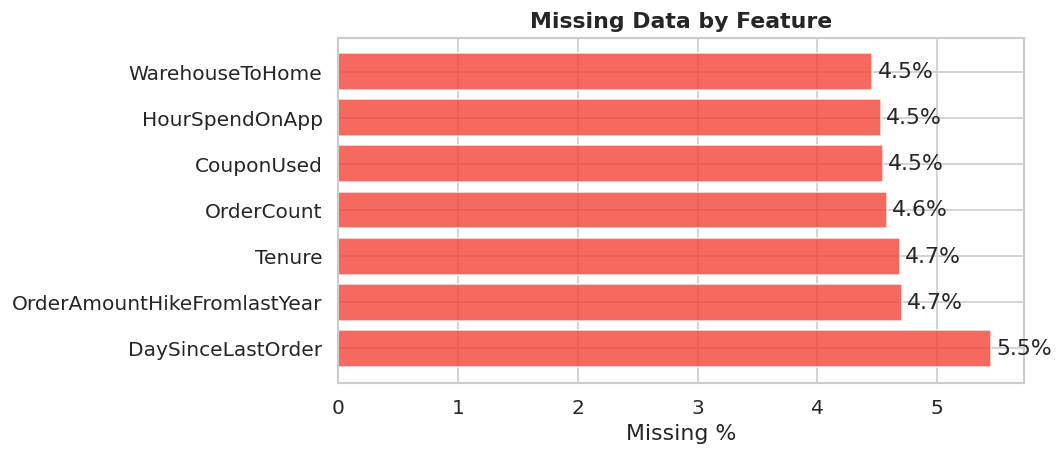

                             Missing Count  Missing %
DaySinceLastOrder                      307       5.45
OrderAmountHikeFromlastYear            265       4.71
Tenure                                 264       4.69
OrderCount                             258       4.58
CouponUsed                             256       4.55
HourSpendOnApp                         255       4.53
WarehouseToHome                        251       4.46


In [19]:
# ── Missing values ───────────────────────────────────────────────────────────
miss = df.isnull().sum()
miss_pct = (miss / len(df) * 100).round(2)
miss_df = pd.DataFrame({'Missing Count': miss, 'Missing %': miss_pct})
miss_df = miss_df[miss_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(miss_df.index, miss_df['Missing %'], color='#F44336', alpha=0.8)
ax.bar_label(bars, labels=[f"{v:.1f}%" for v in miss_df['Missing %']], padding=3)
ax.set_xlabel('Missing %')
ax.set_title('Missing Data by Feature', fontweight='bold')
plt.tight_layout()
plt.show()

print(miss_df)

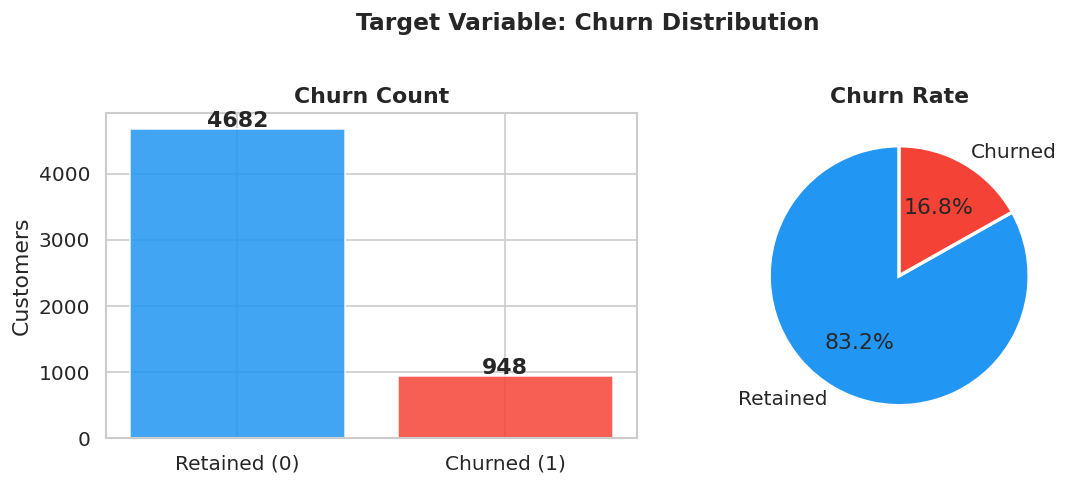

Churn Rate: 16.8%  |  Retained: 83.2%


In [20]:
# ── Target distribution ──────────────────────────────────────────────────────
churn_counts = df['Churn'].value_counts()
churn_pct    = df['Churn'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(['Retained (0)', 'Churned (1)'], churn_counts.values,
            color=['#2196F3', '#F44336'], alpha=0.85, edgecolor='white')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')
axes[0].set_title('Churn Count', fontweight='bold')
axes[0].set_ylabel('Customers')

axes[1].pie(churn_pct.values, labels=['Retained', 'Churned'],
            colors=['#2196F3', '#F44336'], autopct='%1.1f%%',
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Churn Rate', fontweight='bold')

plt.suptitle('Target Variable: Churn Distribution', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f"Churn Rate: {churn_pct[1]:.1f}%  |  Retained: {churn_pct[0]:.1f}%")

## 3. Exploratory Data Analysis — Key Business Questions

| # | Business Question |
|---|---|
| BQ1 | Which customer tenure segments churn the most? |
| BQ2 | Does city tier affect churn? |
| BQ3 | Which payment methods are associated with higher churn? |
| BQ4 | Which product categories are linked to churn? |
| BQ5 | How does customer satisfaction score relate to churn? |
| BQ6 | Do complainers churn more? |
| BQ7 | Does cashback or order amount hike affect loyalty? |
| BQ8 | How does login device preference relate to churn? |
| BQ9 | What does the correlation matrix reveal about churn drivers? |
| BQ10 | What does the customer segment profile look like (RFM-style)? |

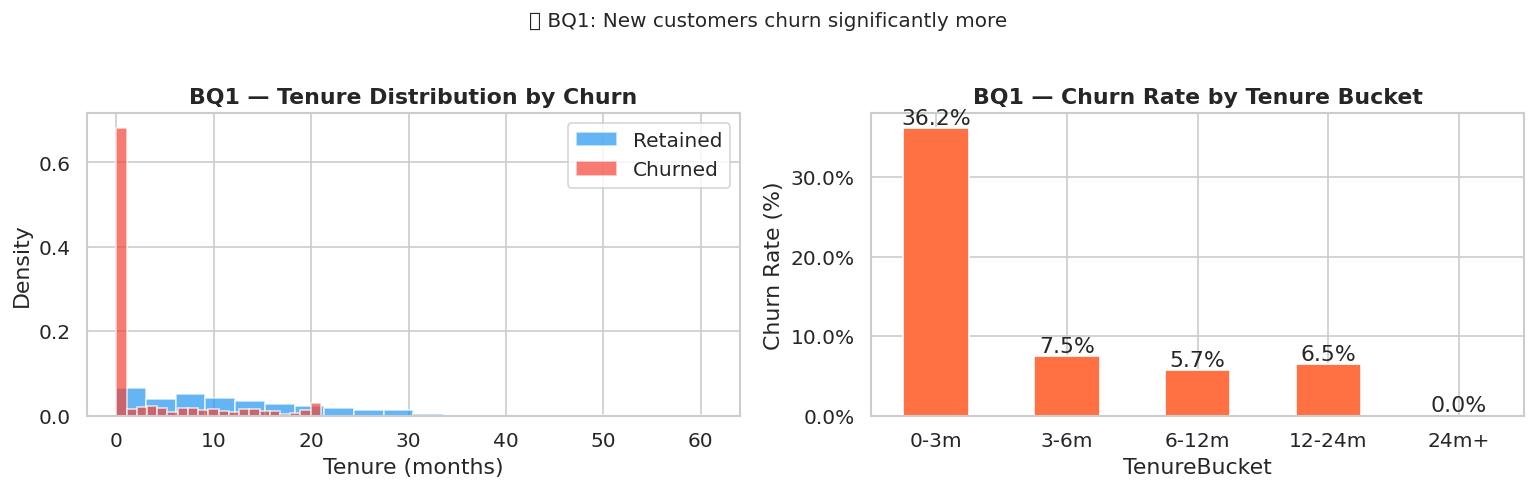

In [21]:
# ── BQ1: Tenure vs Churn ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Distribution
for label, grp in df.groupby('Churn'):
    axes[0].hist(grp['Tenure'].dropna(), bins=20, alpha=0.7,
                 label='Churned' if label == 1 else 'Retained',
                 color='#F44336' if label == 1 else '#2196F3', density=True)
axes[0].set_xlabel('Tenure (months)')
axes[0].set_ylabel('Density')
axes[0].set_title('BQ1 — Tenure Distribution by Churn', fontweight='bold')
axes[0].legend()

# Churn rate by tenure bucket
df['TenureBucket'] = pd.cut(df['Tenure'], bins=[0, 3, 6, 12, 24, 62],
                             labels=['0-3m', '3-6m', '6-12m', '12-24m', '24m+'])
tenure_churn = df.groupby('TenureBucket', observed=True)['Churn'].mean() * 100
tenure_churn.plot(kind='bar', ax=axes[1], color='#FF7043', edgecolor='white', rot=0)
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_title('BQ1 — Churn Rate by Tenure Bucket', fontweight='bold')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():.1f}%",
                     (p.get_x() + p.get_width()/2, p.get_height()+0.5), ha='center')

plt.suptitle('🔍 BQ1: New customers churn significantly more', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## BQ1 — Does Tenure Affect Churn?

Churn is almost entirely a **new customer problem**. Customers in their first 3 months
churn at **36.2%** — roughly 5× the rate of any other segment. Beyond 6 months, churn
stabilizes at ~6% and effectively reaches **0% after 2 years**.

The density plot confirms this: churned customers are overwhelmingly concentrated
at tenure = 0–2 months, while retained customers spread evenly across the full range.

### Key Takeaways
- **The first 3 months are the highest-risk window** — if a customer survives it, they are very likely to stay long-term
- There is a clear **loyalty threshold around 6 months** — past this point churn drops sharply and stays flat
- Long-tenured customers (24m+) show virtually zero churn — they are essentially permanently retained

### Business Recommendation
Invest heavily in **onboarding experience and early engagement** (first 90 days):
early incentives, personalized nudges, and proactive support during this window
will have the highest retention ROI of any intervention in the pipeline.

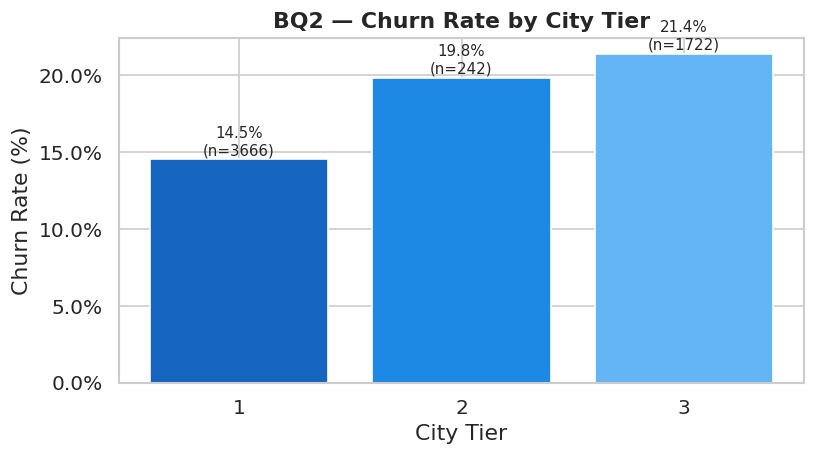

In [22]:
# ── BQ2: City Tier vs Churn ──────────────────────────────────────────────────
city_churn = df.groupby('CityTier')['Churn'].mean() * 100
city_counts = df.groupby('CityTier')['Churn'].count()

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(city_churn.index.astype(str), city_churn.values,
              color=['#1565C0', '#1E88E5', '#64B5F6'], edgecolor='white')
for bar, cnt in zip(bars, city_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f"{bar.get_height():.1f}%\n(n={cnt})", ha='center', fontsize=9)
ax.set_xlabel('City Tier')
ax.set_ylabel('Churn Rate (%)')
ax.set_title('BQ2 — Churn Rate by City Tier', fontweight='bold')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout()
plt.show()

## BQ2 — Does City Tier Affect Churn?

Churn increases steadily as city tier number rises: **14.5% → 19.8% → 21.4%**
for Tiers 1, 2, and 3 respectively. Tier 1 (major metros) retains customers best,
while Tier 3 (smaller cities) loses nearly 1 in 5 customers.

Note that **Tier 1 holds the vast majority of customers (n=3,666)**, making it
the most operationally important segment, while Tier 2 is a very small sample
(n=242) and should be interpreted with caution.

### Key Takeaways
- **Geography is a moderate churn signal** — ~7 percentage point spread across tiers
- Smaller cities likely suffer from **weaker logistics, longer delivery times,
  and fewer payment options** — all friction points that drive churn
- Tier 1 customers are both the largest and most loyal segment

### Business Recommendation
Prioritize **logistics and delivery quality improvements in Tier 3 cities**
before acquiring more customers there. Expanding the customer base in a
high-churn geography without fixing the root cause will accelerate losses.

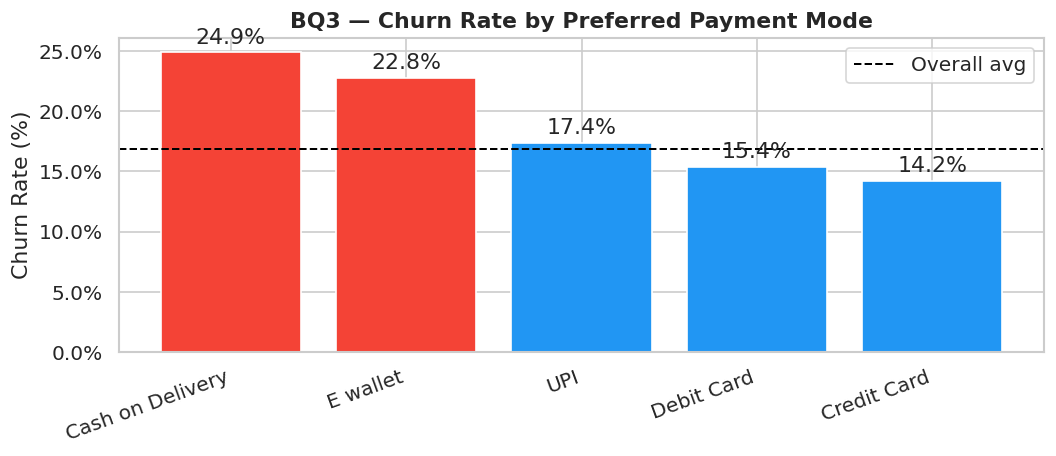

In [23]:
# ── BQ3: Payment Mode vs Churn ───────────────────────────────────────────────
pay_churn = df.groupby('PreferredPaymentMode')['Churn'].mean().sort_values(ascending=False) * 100

fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#F44336' if v > 20 else '#2196F3' for v in pay_churn.values]
bars = ax.bar(pay_churn.index, pay_churn.values, color=colors, edgecolor='white')
ax.bar_label(bars, labels=[f"{v:.1f}%" for v in pay_churn.values], padding=3)
ax.set_ylabel('Churn Rate (%)')
ax.set_title('BQ3 — Churn Rate by Preferred Payment Mode', fontweight='bold')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.xticks(rotation=20, ha='right')
ax.axhline(df['Churn'].mean()*100, color='black', linestyle='--', linewidth=1.2, label='Overall avg')
ax.legend()
plt.tight_layout()
plt.show()

## BQ3 — Does Payment Method Affect Churn?

Two payment modes stand clearly above the overall average (~17%):
**Cash on Delivery at 24.9%** and **E-wallet at 22.8%**. Card-based payments
(Debit 15.4%, Credit 14.2%) perform best, sitting below the average.

### Key Takeaways
- **CoD is the highest-risk payment method** — it signals lower digital commitment
  and likely correlates with Tier 3 customers who have fewer payment alternatives
- **E-wallet churners** are surprising given their digital savviness — they may be
  deal-hunters who switch platforms for better cashback offers
- **Card users are the most loyal** — automatic payments and higher purchase intent
  reduce friction and increase stickiness

### Business Recommendation
- **Incentivize CoD users to switch to digital payments** with first-time card/UPI
  cashback bonuses — this single conversion could measurably reduce churn
- **E-wallet users need loyalty hooks** beyond cashback (exclusive deals, early access)
  to prevent them from hopping to competitors

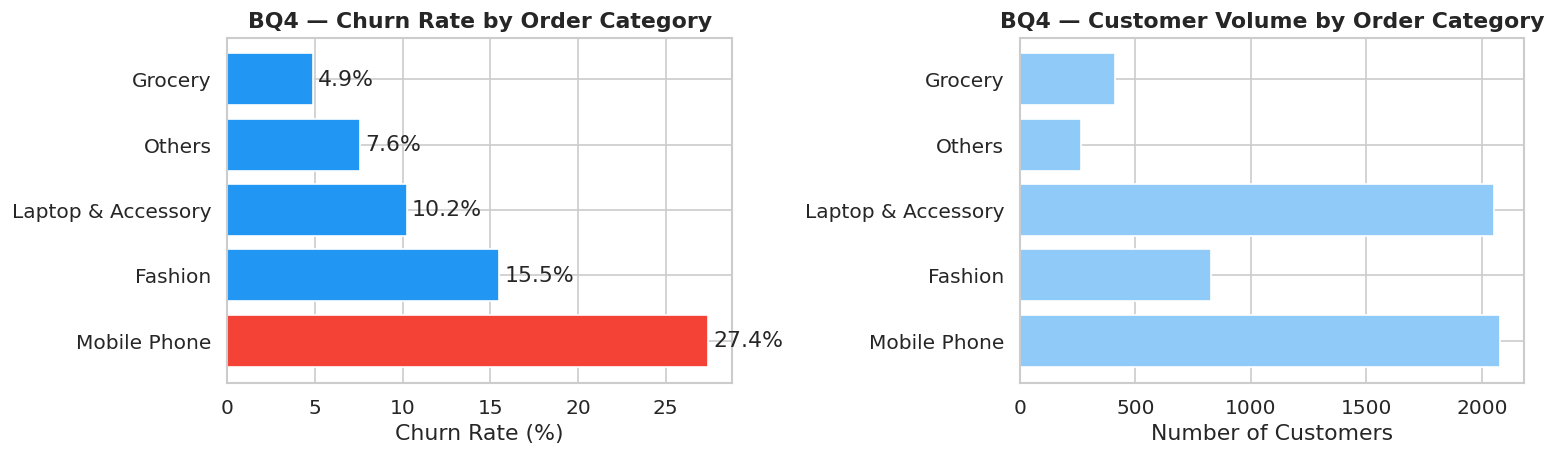

In [24]:
# ── BQ4: Order Category vs Churn ─────────────────────────────────────────────
cat_churn = df.groupby('PreferedOrderCat')['Churn'].mean().sort_values(ascending=False) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Churn rate
bars = axes[0].barh(cat_churn.index, cat_churn.values,
                    color=['#F44336' if v > 20 else '#2196F3' for v in cat_churn.values],
                    edgecolor='white')
axes[0].bar_label(bars, labels=[f"{v:.1f}%" for v in cat_churn.values], padding=3)
axes[0].set_title('BQ4 — Churn Rate by Order Category', fontweight='bold')
axes[0].set_xlabel('Churn Rate (%)')

# Volume
cat_vol = df.groupby('PreferedOrderCat')['Churn'].count().reindex(cat_churn.index)
axes[1].barh(cat_vol.index, cat_vol.values, color='#90CAF9', edgecolor='white')
axes[1].set_title('BQ4 — Customer Volume by Order Category', fontweight='bold')
axes[1].set_xlabel('Number of Customers')

plt.tight_layout()
plt.show()

## BQ4 — Does Preferred Order Category Affect Churn?

**Mobile Phone buyers churn at 27.4%** — by far the highest of any category and
well above the overall average (~17%). What makes this critical is that Mobile Phone
is also the **largest customer segment (~2,050 customers)**, meaning this isn't a
niche problem — it's the single biggest churn risk in the dataset by volume.

Grocery sits at the opposite end with just **4.9% churn**, the most loyal category,
likely driven by habitual repeat purchasing behavior. Laptop & Accessory (10.2%)
also performs well despite being equally large in volume.

### Key Takeaways
- **Mobile Phone = high churn + high volume = highest business impact** — this
  category alone likely accounts for a disproportionate share of total churned customers
- **Grocery buyers are the stickiest** — repeat-purchase categories naturally
  build habit-driven loyalty
- Mobile phone purchases are often **one-time high-value transactions** with no
  natural reason to return, unlike groceries or fashion

### Business Recommendation
- Launch **post-purchase engagement programs** specifically for Mobile Phone buyers:
  accessories cross-sells, warranty upsells, and trade-in programs to create
  a reason to return
- Use Grocery's loyalty model as a blueprint — **subscription or auto-replenishment**
  mechanics drive the habitual behavior that prevents churn

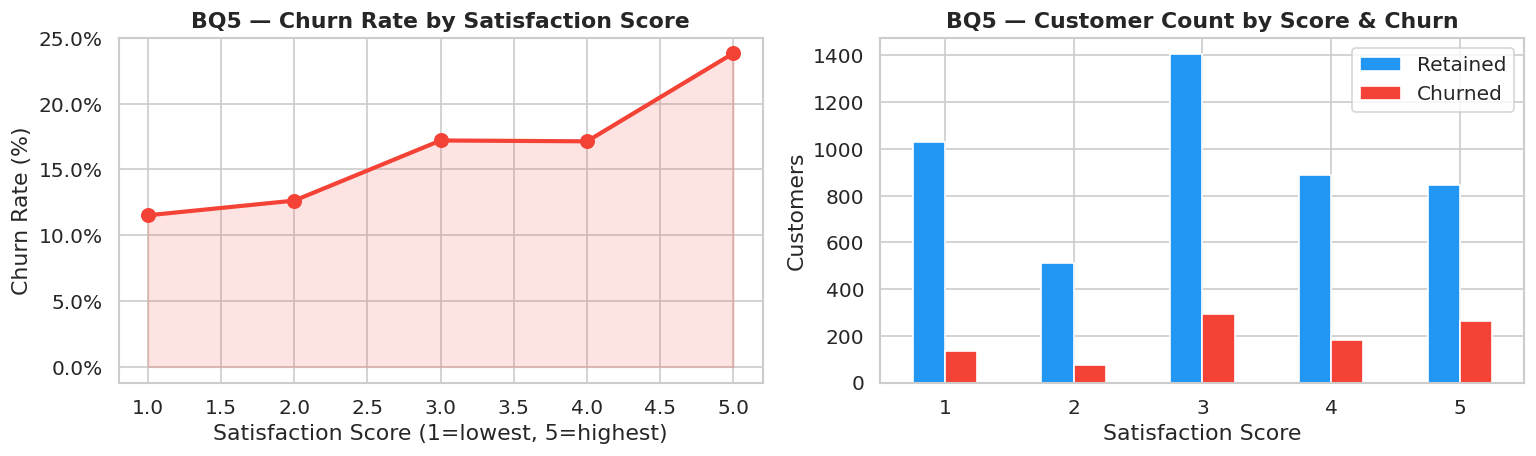

In [25]:
# ── BQ5: Satisfaction Score vs Churn ─────────────────────────────────────────
sat_churn = df.groupby('SatisfactionScore')['Churn'].mean() * 100
sat_counts = df.groupby('SatisfactionScore').size()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Churn rate by score
axes[0].plot(sat_churn.index, sat_churn.values, marker='o', color='#F44336', linewidth=2.5, markersize=8)
axes[0].fill_between(sat_churn.index, sat_churn.values, alpha=0.15, color='#F44336')
axes[0].set_xlabel('Satisfaction Score (1=lowest, 5=highest)')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_title('BQ5 — Churn Rate by Satisfaction Score', fontweight='bold')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())

# Distribution
df_plot = df.groupby(['SatisfactionScore', 'Churn']).size().unstack(fill_value=0)
df_plot.plot(kind='bar', ax=axes[1], color=['#2196F3', '#F44336'],
             edgecolor='white', rot=0)
axes[1].set_xlabel('Satisfaction Score')
axes[1].set_ylabel('Customers')
axes[1].set_title('BQ5 — Customer Count by Score & Churn', fontweight='bold')
axes[1].legend(['Retained', 'Churned'])

plt.tight_layout()
plt.show()

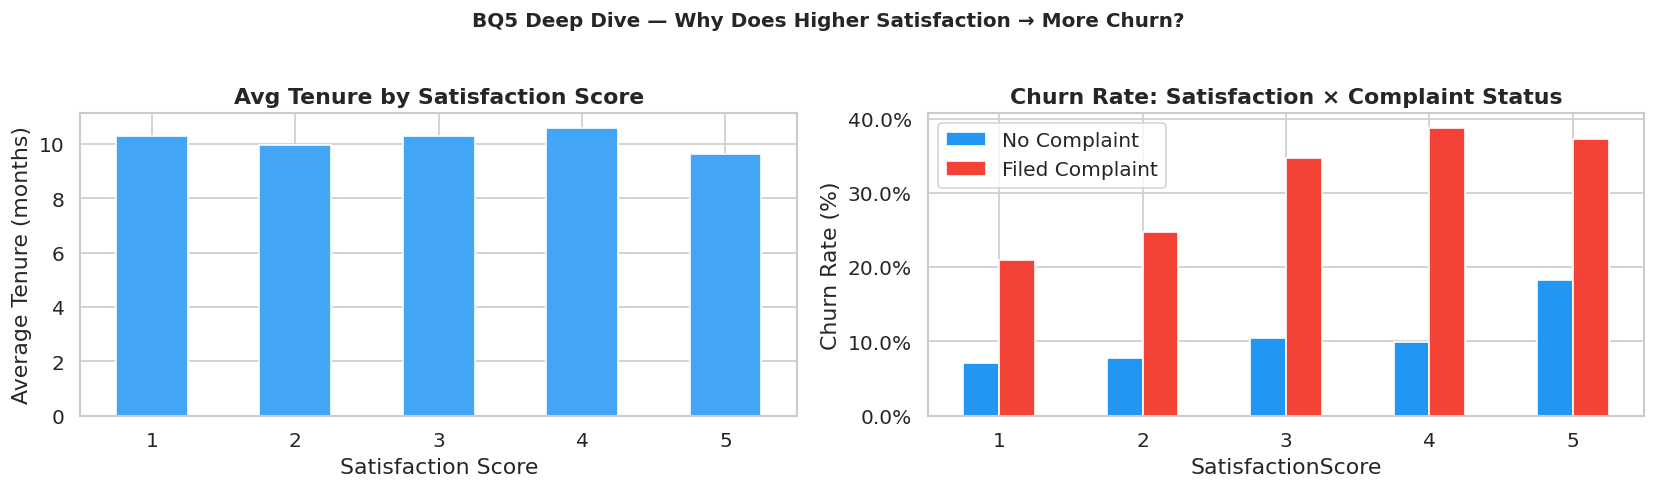

Churn                 0    1
SatisfactionScore           
1                  11.1  4.0
2                  10.8  4.1
3                  11.6  3.6
4                  11.9  3.7
5                  11.8  2.4


In [27]:
# ── BQ5 Deep Dive: Satisfaction × Tenure × Churn ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Satisfaction vs Tenure (are high scorers newer customers?)
df.groupby('SatisfactionScore')['Tenure'].mean().plot(
    kind='bar', ax=axes[0], color='#42A5F5', edgecolor='white', rot=0
)
axes[0].set_title('Avg Tenure by Satisfaction Score', fontweight='bold')
axes[0].set_ylabel('Average Tenure (months)')
axes[0].set_xlabel('Satisfaction Score')

# Churn rate: Satisfaction × Complain (is dissatisfaction masked by complaints?)
pivot = df.groupby(['SatisfactionScore', 'Complain'])['Churn'].mean().unstack() * 100
pivot.columns = ['No Complaint', 'Filed Complaint']
pivot.plot(kind='bar', ax=axes[1], color=['#2196F3', '#F44336'], edgecolor='white', rot=0)
axes[1].set_title('Churn Rate: Satisfaction × Complaint Status', fontweight='bold')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].legend()

plt.suptitle('BQ5 Deep Dive — Why Does Higher Satisfaction → More Churn?',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Print the cross-tab
print(df.groupby(['SatisfactionScore', 'Churn'])['Tenure'].mean().unstack().round(1))

## BQ5 Analysis - Does Customer Satisfaction Drive Churn?

### Surface Finding (Misleading at First Glance)
The initial churn-rate-by-satisfaction plot shows a **counterintuitive positive trend**:
higher satisfaction scores are associated with *higher* churn rates, peaking at **~24% for score 5**.
This challenges the standard assumption that happier customers stay longer.

---

### Diagnostic Investigation

#### Tenure is NOT the confounder
Average tenure is nearly flat across all satisfaction scores (~10 months each),
ruling out the hypothesis that newer (more enthusiastic) customers are inflating
high-score churn rates.

#### Complaints ARE the real driver
Once we split churn rate by **complaint status**, the satisfaction score loses
its apparent effect entirely:

| Segment | Churn Rate Range (across all scores) |
|---|---|
| No Complaint | 7% – 19% → low & relatively flat |
| Filed Complaint | 21% – 39% → consistently high |

The satisfaction score gradient disappears when complaint status is controlled for.
**Complaint filing is the dominant signal; satisfaction score is riding on its coattails.**

---

### Root Cause Hypothesis
> Customers who file complaints tend to give **higher satisfaction scores**
> — likely because surveys are triggered post-resolution, capturing a momentary
> relief rather than genuine long-term loyalty. Yet these same customers churn
> at 2–3× the base rate because the underlying trust was already damaged.

In other words: **resolving a complaint ≠ retaining the customer.**
The complaint experience leaves a scar even when the ticket is closed.

---

### Key Takeaways

- **Satisfaction score alone is a poor churn predictor** — do not rely on it in isolation
- **`Complain` is the most actionable single feature** in this dataset for churn risk
- Post-complaint satisfaction surveys create a **measurement bias** that masks the true loyalty signal
- High-satisfaction churners are not "happy leavers" — they are largely **complaint filers
  whose trust was broken despite resolution**



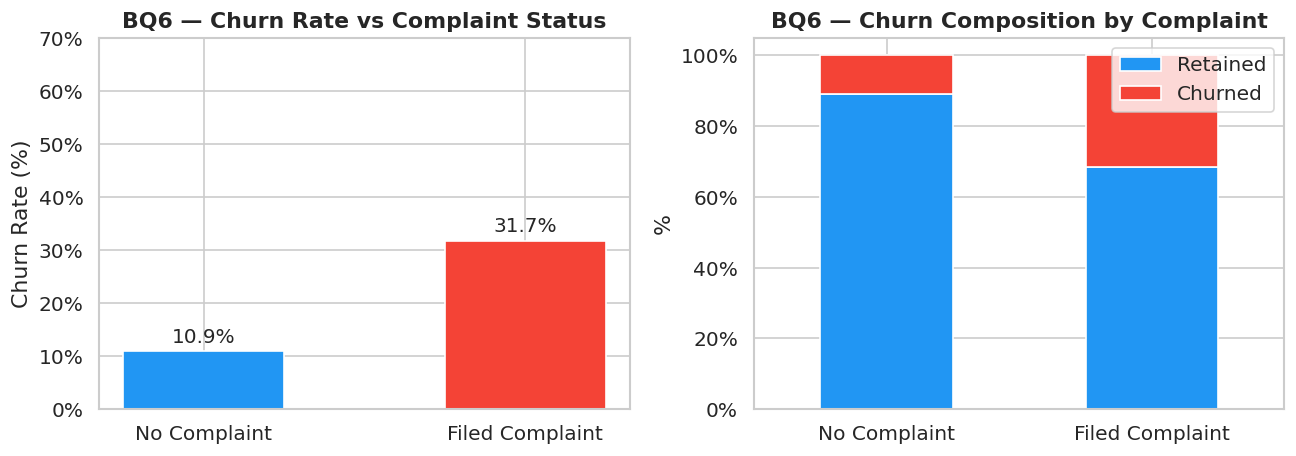

In [28]:
# ── BQ6: Complaints vs Churn ─────────────────────────────────────────────────
complain_churn = df.groupby('Complain')['Churn'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

bars = axes[0].bar(['No Complaint', 'Filed Complaint'], complain_churn.values,
                   color=['#2196F3', '#F44336'], edgecolor='white', width=0.5)
axes[0].bar_label(bars, labels=[f"{v:.1f}%" for v in complain_churn.values], padding=3, fontsize=12)
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_title('BQ6 — Churn Rate vs Complaint Status', fontweight='bold')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[0].set_ylim(0, 70)

# Segmented stacked bar
ct = pd.crosstab(df['Complain'], df['Churn'], normalize='index') * 100
ct.index = ['No Complaint', 'Filed Complaint']
ct.columns = ['Retained', 'Churned']
ct.plot(kind='bar', stacked=True, ax=axes[1], color=['#2196F3', '#F44336'],
        edgecolor='white', rot=0)
axes[1].set_ylabel('%')
axes[1].set_title('BQ6 — Churn Composition by Complaint', fontweight='bold')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

## BQ6 — Do Complainers Churn More?

The gap is stark and unambiguous: customers who filed a complaint churn at **31.7%**
versus just **10.9%** for those who didn't — a **3× churn multiplier**. The composition
chart reinforces this: nearly 1 in 3 complaint filers leaves, compared to roughly
1 in 9 non-complainers.

### Key Takeaways
- **`Complain` is the single strongest binary churn predictor in the dataset** —
  a 20.8 percentage point gap leaves no ambiguity
- Filing a complaint is not just a symptom of dissatisfaction — it is a
  **leading indicator of departure**, regardless of whether the issue was resolved
- As established in BQ5, even customers who rate satisfaction highly after
  a complaint still churn at elevated rates — **resolution ≠ retention**

### Business Recommendation
- **Treat every complaint as a churn alert** — trigger an automatic CRM retention
  workflow the moment a complaint is filed, not after it's closed
- Track **time-to-resolution** as a KPI — the longer a complaint stays open,
  the higher the churn probability climbs
- Identify the **top complaint categories** and fix them upstream to reduce
  complaint volume altogether, which is the only sustainable churn reduction lever

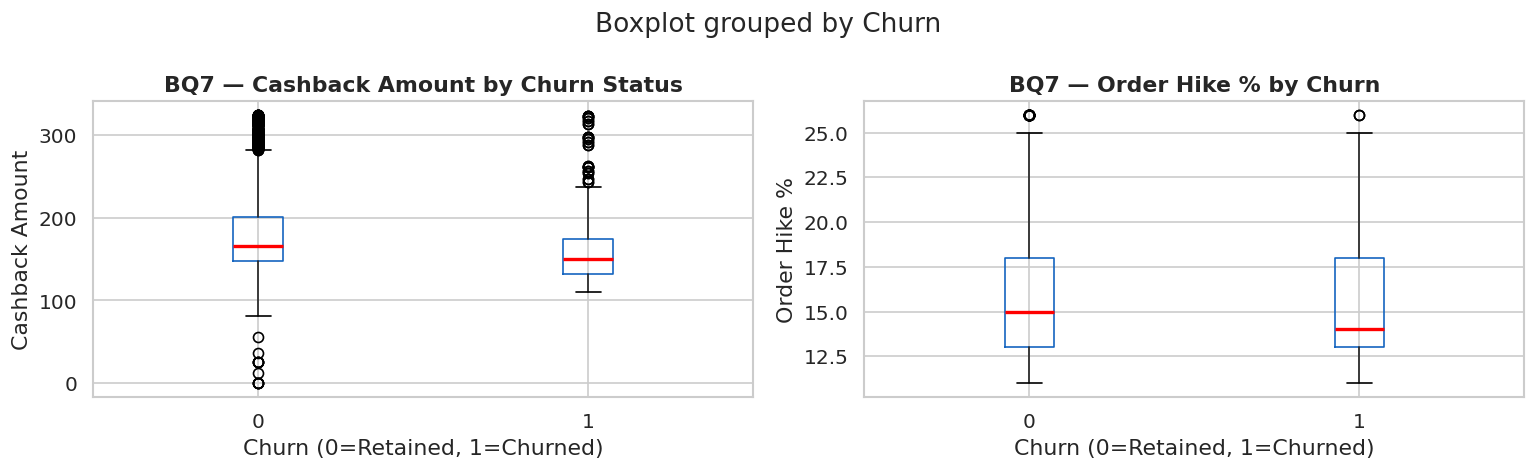

Cashback mean by churn:
Churn
0    180.64
1    160.37
Name: CashbackAmount, dtype: float64


In [29]:
# ── BQ7: Cashback & Order Hike vs Churn ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Cashback boxplot
df.boxplot(column='CashbackAmount', by='Churn', ax=axes[0],
           boxprops=dict(color='#1565C0'), medianprops=dict(color='red', linewidth=2))
axes[0].set_title('BQ7 — Cashback Amount by Churn Status', fontweight='bold')
axes[0].set_xlabel('Churn (0=Retained, 1=Churned)')
axes[0].set_ylabel('Cashback Amount')
plt.sca(axes[0])
plt.title('BQ7 — Cashback Amount by Churn Status', fontweight='bold')

# Order hike
df.boxplot(column='OrderAmountHikeFromlastYear', by='Churn', ax=axes[1],
           boxprops=dict(color='#1565C0'), medianprops=dict(color='red', linewidth=2))
axes[1].set_title('BQ7 — Order Amount Hike (%) by Churn', fontweight='bold')
axes[1].set_xlabel('Churn (0=Retained, 1=Churned)')
axes[1].set_ylabel('Order Hike %')
plt.sca(axes[1])
plt.title('BQ7 — Order Hike % by Churn', fontweight='bold')

plt.tight_layout()
plt.show()

print('Cashback mean by churn:')
print(df.groupby('Churn')['CashbackAmount'].mean().round(2))

## BQ7 — Do Cashback & Order Hike Influence Churn?

Both variables show differences between churned and retained customers,
but neither is a dramatic standalone predictor.

**Cashback:** Retained customers receive a higher average cashback ($180.64) vs. churned customers ($160.37) — a $20 gap. The boxplot shows churners
have a tighter, lower distribution, suggesting they are receiving less
platform generosity before leaving.

**Order Hike %:** Churners show a slightly *lower* median order hike than
retained customers, with a more compressed distribution. Counterintuitively,
customers whose spending grew less are more likely to churn.

### Key Takeaways
- **Cashback is a loyalty lever, not just a discount** — the $20 gap suggests
  retained customers are being rewarded more, or are engaging in ways that
  naturally earn more cashback
- **Low order growth = disengagement signal** — customers who aren't increasing
  their spend are quietly drifting toward exit
- Neither variable alone is a strong predictor, but combined they paint a
  picture of **a customer gradually becoming less invested in the platform**

### Business Recommendation
- **Proactively increase cashback offers for stagnant or declining spenders**
  before they reach the churn decision point
- Flag customers whose order amount growth is flat or negative for 2+ consecutive
  months as early churn risk — intervene with personalized offers

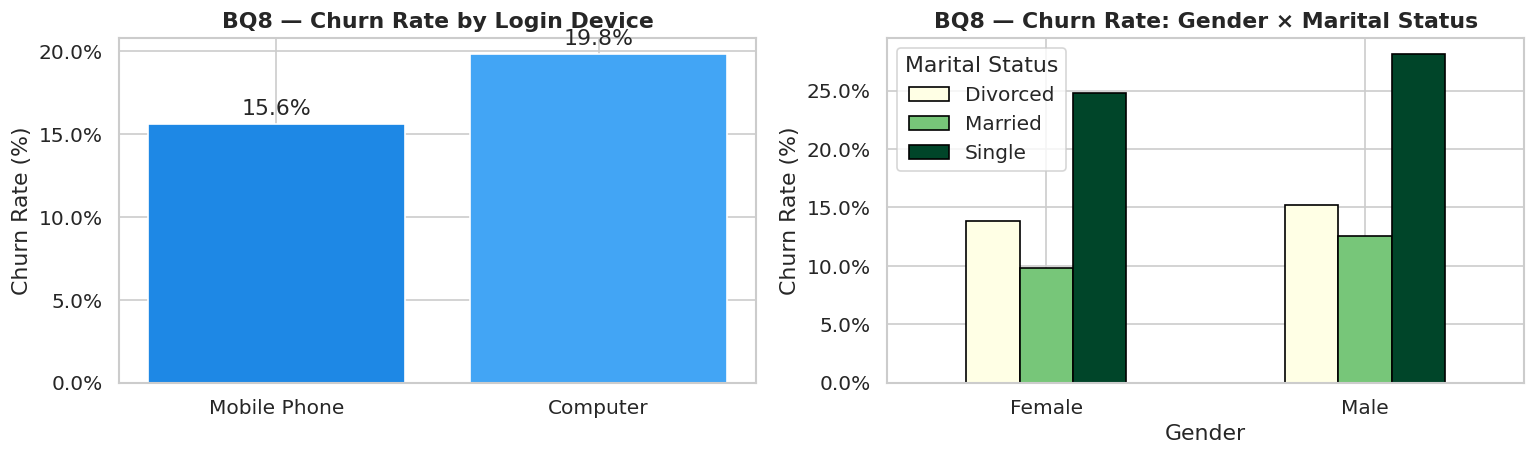

In [44]:
# ── BQ8: Login Device & Gender vs Churn ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

dev_churn = df.groupby('PreferredLoginDevice')['Churn'].mean().sort_values() * 100
bars = axes[0].bar(dev_churn.index, dev_churn.values,
                   color=['#1E88E5', '#42A5F5', '#EF5350'], edgecolor='white')
axes[0].bar_label(bars, labels=[f"{v:.1f}%" for v in dev_churn.values], padding=3)
axes[0].set_title('BQ8 — Churn Rate by Login Device', fontweight='bold')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())

gender_churn = df.groupby(['Gender', 'MaritalStatus'])['Churn'].mean() * 100
gender_churn.unstack().plot(kind='bar', ax=axes[1], colormap='YlGn', edgecolor='black', rot=0)
axes[1].set_title('BQ8 — Churn Rate: Gender × Marital Status', fontweight='bold')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].legend(title='Marital Status')

plt.tight_layout()
plt.show()

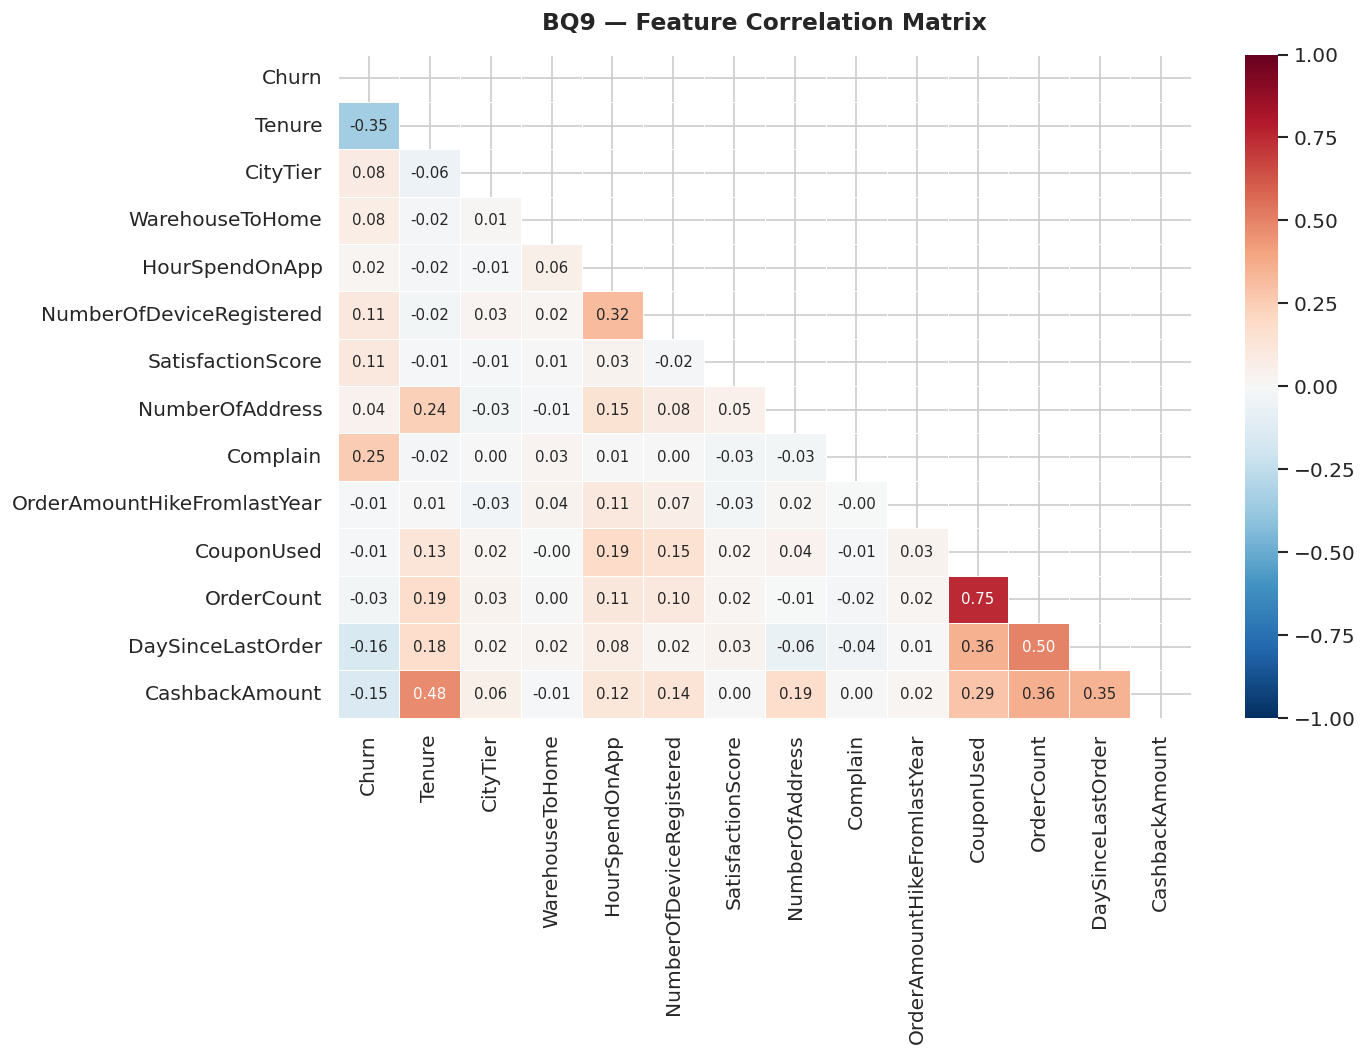


Top correlations with Churn (absolute):
Tenure                      0.349408
Complain                    0.250188
DaySinceLastOrder           0.160757
CashbackAmount              0.154118
NumberOfDeviceRegistered    0.107939
SatisfactionScore           0.105481
CityTier                    0.084703
WarehouseToHome             0.076630
NumberOfAddress             0.043931
OrderCount                  0.028697
Name: Churn, dtype: float64


In [31]:
# ── BQ9: Correlation Heatmap ──────────────────────────────────────────────────
num_cols = df.select_dtypes(include=np.number).columns.drop('CustomerID')
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5, ax=ax, vmin=-1, vmax=1,
            annot_kws={'size': 9})
ax.set_title('BQ9 — Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# Top correlations with Churn
churn_corr = corr['Churn'].drop('Churn').abs().sort_values(ascending=False)
print('\nTop correlations with Churn (absolute):')
print(churn_corr.head(10))

## BQ9 — What Does the Correlation Matrix Reveal?

### Top Churn Correlates (absolute value)
| Feature | Correlation | Direction |
|---|---|---|
| Tenure | 0.35 | Negative — longer tenure = less churn |
| Complain | 0.25 | Positive — complaints drive churn |
| DaySinceLastOrder | 0.16 | Positive — longer inactivity = more churn |
| CashbackAmount | 0.15 | Negative — more cashback = less churn |
| NumberOfDeviceRegistered | 0.11 | Positive — more devices = slightly more churn |
| SatisfactionScore | 0.11 | Positive — misleading, as proven in BQ5 |

### Notable Feature-to-Feature Correlations
- **OrderCount ↔ CouponUsed (0.75)** — the strongest pair in the matrix;
  heavy orderers are also heavy coupon users, suggesting a deal-driven segment
- **CashbackAmount ↔ Tenure (0.48)** — longer customers earn more cashback,
  reinforcing that cashback is a loyalty reward, not just an acquisition tool
- **DaySinceLastOrder ↔ CouponUsed (0.50)** and **↔ OrderCount (0.36)** —
  inactive customers are also low coupon/order activity customers, a consistent
  disengagement pattern

### Key Takeaways
- **No single feature dominates churn** — the highest correlation is only 0.35,
  meaning churn is genuinely multi-factorial and a model will outperform any
  single rule-based approach
- **Tenure and Complain are the two clean, actionable signals** — all others
  are weaker or confounded
- The **OrderCount–CouponUsed multicollinearity** should be addressed in
  modeling — consider dropping one or engineering a ratio instead
- **SatisfactionScore's 0.11 correlation is spurious** — driven by its
  relationship with Complain, not genuine satisfaction signal (confirmed in BQ5)

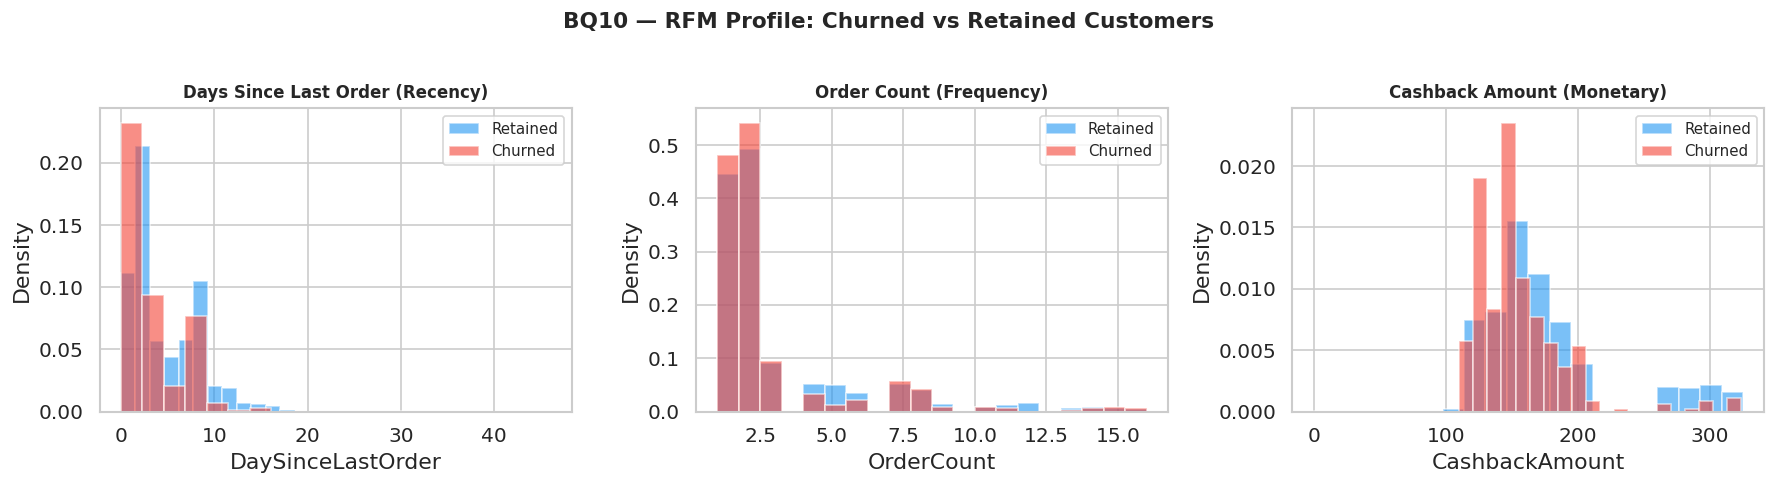

In [32]:
# ── BQ10: Customer Segmentation — RFM-style Analysis ─────────────────────────
# Recency = DaySinceLastOrder (lower = better)
# Frequency = OrderCount
# Monetary = CashbackAmount (proxy for spend)

rfm = df[['DaySinceLastOrder', 'OrderCount', 'CashbackAmount', 'Churn']].dropna()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, label, color in zip(
    axes,
    ['DaySinceLastOrder', 'OrderCount', 'CashbackAmount'],
    ['Days Since Last Order (Recency)', 'Order Count (Frequency)', 'Cashback Amount (Monetary)'],
    ['#42A5F5', '#66BB6A', '#FF7043']
):
    for churn_val, lbl, c in [(0, 'Retained', '#2196F3'), (1, 'Churned', '#F44336')]:
        subset = rfm[rfm['Churn'] == churn_val][col]
        ax.hist(subset, bins=20, alpha=0.6, label=lbl, color=c, density=True)
    ax.set_title(f'{label}', fontweight='bold', fontsize=10)
    ax.set_xlabel(col)
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)

plt.suptitle('BQ10 — RFM Profile: Churned vs Retained Customers', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## BQ10 — What Is the RFM Profile of Churned vs Retained Customers?

**Recency:** Both groups are heavily concentrated in the 0–5 day range, meaning
recency alone doesn't cleanly separate churners from retained customers. However,
churners have a sharper spike at day 0–2, suggesting they made one last order
right before leaving — a **"goodbye purchase"** pattern.

**Frequency:** Churners are overwhelmingly concentrated at **1–2 orders**, while
retained customers show a broader, flatter distribution extending to 10+ orders.
This is the clearest RFM separator — churners are essentially **one-time or
two-time buyers** who never developed a repeat habit.

**Monetary:** The distributions overlap heavily in the $100–$200 range with
churners peaking slightly lower (~$120–$150) vs retained (~$150–$180),
consistent with the cashback gap found in BQ7. Not a strong standalone signal.

### Key Takeaways
- **Frequency is the dominant RFM dimension for churn** — the inability to
  convert a first/second purchase into a third is where retention is lost
- **Recency is misleading here** — churners aren't inactive before leaving,
  they transact recently then disappear, making recency a lagging not leading indicator
- **Monetary value is secondary** — churn is not primarily a high-vs-low spender story

### Business Recommendation
- The critical intervention point is **between order 1 and order 3** — design
  a triggered re-engagement sequence after the first purchase to push customers
  toward a second and third order, as habit formation is the real retention mechanism
- Do not rely on purchase recency as an early warning system — by the time
  a customer goes inactive, the churn decision is likely already made

## 4. Feature Engineering

In [34]:
df_fe = df.copy()

# 1. Engagement score — hours × devices
df_fe['EngagementScore'] = df_fe['HourSpendOnApp'] * df_fe['NumberOfDeviceRegistered']

# 2. Order frequency-per-day (avoid div0)
df_fe['OrderFreqPerDay'] = df_fe['OrderCount'] / (df_fe['DaySinceLastOrder'] + 1)

# 3. Cashback-to-order ratio
df_fe['CashbackPerOrder'] = df_fe['CashbackAmount'] / (df_fe['OrderCount'] + 1)

# 4. Tenure bucket (encoded)
df_fe['TenureBucketEnc'] = pd.cut(df_fe['Tenure'],
                                   bins=[0, 3, 6, 12, 24, 62],
                                   labels=[0, 1, 2, 3, 4]).astype(float)

# 5. Address diversity (how spread the customer is)
df_fe['HighAddressCount'] = (df_fe['NumberOfAddress'] > 5).astype(int)

# Add to Feature Engineering cell
df_fe['ComplainHighSat'] = ((df_fe['Complain'] == 1) & (df_fe['SatisfactionScore'] >= 4)).astype(int)
df_fe['ComplainLowSat']  = ((df_fe['Complain'] == 1) & (df_fe['SatisfactionScore'] <= 2)).astype(int)

print('New features added:', ['EngagementScore', 'OrderFreqPerDay', 'CashbackPerOrder',
                               'TenureBucketEnc', 'HighAddressCount', 'ComplainHighSat', 'ComplainLowSat'])
df_fe[['EngagementScore', 'OrderFreqPerDay', 'CashbackPerOrder']].describe().round(3)

New features added: ['EngagementScore', 'OrderFreqPerDay', 'CashbackPerOrder', 'TenureBucketEnc', 'HighAddressCount', 'ComplainHighSat', 'ComplainLowSat']


,EngagementScore,OrderFreqPerDay,CashbackPerOrder
count,5375.000,5065.000,5372.000
mean,11.133,0.640,56.103
std,4.642,0.563,24.541
min,0.000,0.056,0.000
25%,8.000,0.333,40.890
50%,12.000,0.500,56.407
75%,15.000,1.000,68.870
max,25.000,9.000,149.295


## 5. Preprocessing

In [48]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import OrdinalEncoder
# Drop CustomerID and helper columns
FEATURES = df_fe.drop(columns=['CustomerID', 'Churn', 'TenureBucket']).columns.tolist()
TARGET   = 'Churn'

X = df_fe[FEATURES]
y = df_fe[TARGET]

# Identify numerical and categorical columns
num_cols = X.select_dtypes(include=np.number).columns.tolist()
cat_cols = X.select_dtypes(include='object').columns.tolist()

print(f'Numerical features ({len(num_cols)}): {num_cols}')
print(f'Categorical features ({len(cat_cols)}): {cat_cols}')

# ── Preprocessing pipelines ──────────────────────────────────────────────────
num_pipe = Pipeline([
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler',  StandardScaler())
])

cat_pipe = Pipeline([
    ('ordinal',  OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)),  # strings → numbers
    ('imputer',  KNNImputer(n_neighbors=5)),   # now KNN can work on them
    ('encoder',  OneHotEncoder(handle_unknown='ignore', sparse_output=False))            # numbers → OHE
])
preprocessor = ColumnTransformer([
    ('num', num_pipe, num_cols),
    ('cat', cat_pipe, cat_cols)
])

# Train-test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f'\nTrain: {X_train.shape} | Test: {X_test.shape}')
print(f'Train churn rate: {y_train.mean():.3f} | Test churn rate: {y_test.mean():.3f}')

Numerical features (20): ['Tenure', 'CityTier', 'WarehouseToHome', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'SatisfactionScore', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount', 'EngagementScore', 'OrderFreqPerDay', 'CashbackPerOrder', 'TenureBucketEnc', 'HighAddressCount', 'ComplainHighSat', 'ComplainLowSat']
Categorical features (5): ['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender', 'PreferedOrderCat', 'MaritalStatus']

Train: (4504, 25) | Test: (1126, 25)
Train churn rate: 0.168 | Test churn rate: 0.169


## 6. Model Training

In [49]:
# ── Fit preprocessor once ─────────────────────────────────────────────────────
X_train_proc = preprocessor.fit_transform(X_train, y_train)
X_test_proc  = preprocessor.transform(X_test)

ohe_features  = preprocessor.named_transformers_['cat']['encoder'].get_feature_names_out(cat_cols).tolist()
feature_names = num_cols + ohe_features

print(f'Processed — Train: {X_train_proc.shape} | Test: {X_test_proc.shape}')

# ── Define models ─────────────────────────────────────────────────────────────
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=SEED),
    'Random Forest':       RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=SEED, n_jobs=-1),
    'SVM':                 SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=SEED),
}

if HAS_XGB:
    scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
    models['XGBoost'] = XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.05,
                                       scale_pos_weight=scale_pos, random_state=SEED,
                                       eval_metric='logloss', verbosity=0)
else:
    models['Gradient Boosting'] = GradientBoostingClassifier(n_estimators=200, max_depth=4,
                                                               learning_rate=0.05, random_state=SEED)

# ── Train & evaluate ──────────────────────────────────────────────────────────
results        = {}
trained_models = {}

for name, clf in models.items():
    clf.fit(X_train_proc, y_train)
    trained_models[name] = clf

    y_pred  = clf.predict(X_test_proc)
    y_proba = clf.predict_proba(X_test_proc)[:, 1]

    results[name] = {
        'AUC-ROC':  roc_auc_score(y_test, y_proba),
        'Avg Prec': average_precision_score(y_test, y_proba),
        'y_pred':   y_pred,
        'y_proba':  y_proba
    }
    print(f'{name}: AUC={results[name]["AUC-ROC"]:.4f}  |  Avg Prec={results[name]["Avg Prec"]:.4f}')

Processed — Train: (4504, 37) | Test: (1126, 37)
Logistic Regression: AUC=0.8882  |  Avg Prec=0.6639
Random Forest: AUC=0.9989  |  Avg Prec=0.9949
SVM: AUC=0.9602  |  Avg Prec=0.8198
XGBoost: AUC=0.9874  |  Avg Prec=0.9408


## 7. Model Evaluation & Comparison

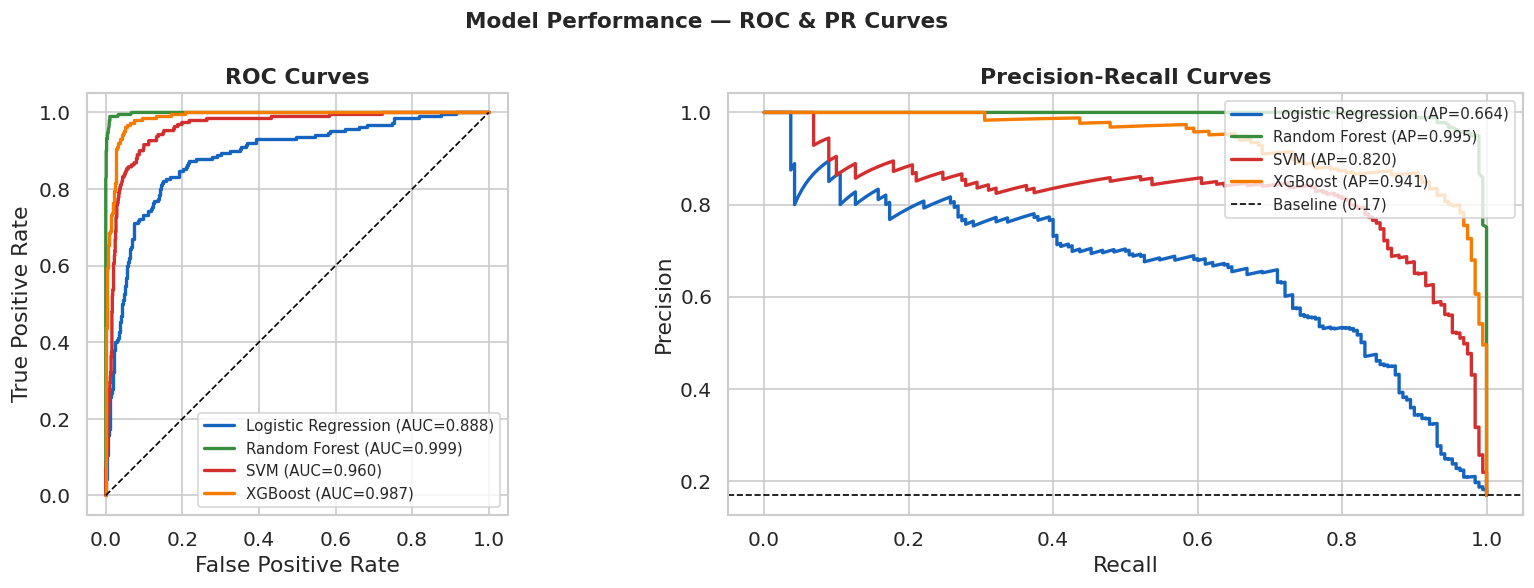

In [50]:
# ── ROC curves ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#1565C0', '#388E3C', '#D32F2F', '#F57C00']

for (name, res), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={res['AUC-ROC']:.3f})",
                 color=color, linewidth=2)

axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves', fontweight='bold')
axes[0].legend(loc='lower right', fontsize=9)
axes[0].set_aspect('equal')

# ── Precision-Recall curves ───────────────────────────────────────────────────
for (name, res), color in zip(results.items(), colors):
    prec, rec, _ = precision_recall_curve(y_test, res['y_proba'])
    axes[1].plot(rec, prec, label=f"{name} (AP={res['Avg Prec']:.3f})",
                 color=color, linewidth=2)

baseline = y_test.mean()
axes[1].axhline(baseline, color='black', linestyle='--', linewidth=1, label=f'Baseline ({baseline:.2f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves', fontweight='bold')
axes[1].legend(loc='upper right', fontsize=9)

plt.suptitle('Model Performance — ROC & PR Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

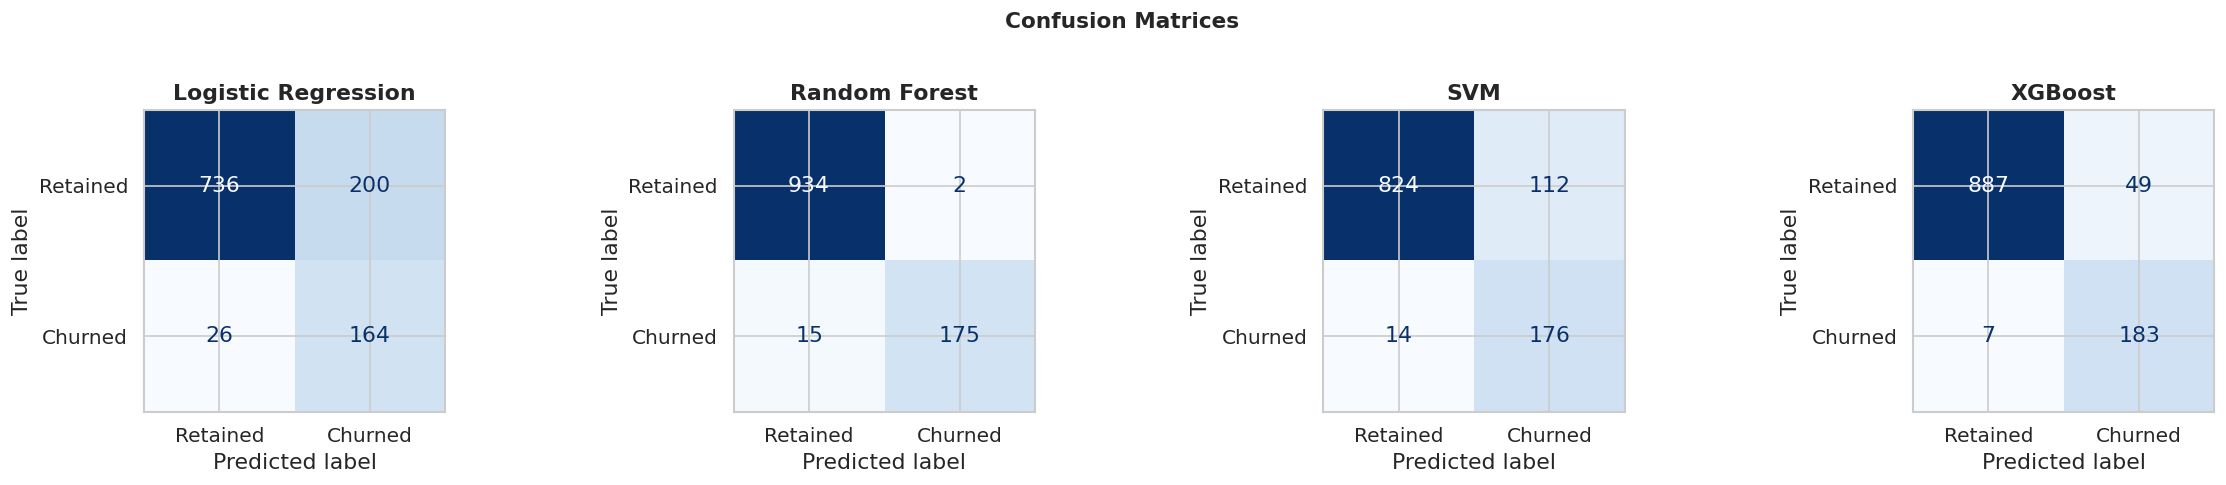

In [51]:
# ── Confusion matrices ────────────────────────────────────────────────────────
n_models = len(results)
fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 4))
if n_models == 1: axes = [axes]

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Retained', 'Churned'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontweight='bold')

plt.suptitle('Confusion Matrices', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [52]:
# ── Classification reports ────────────────────────────────────────────────────
for name, res in results.items():
    print(f'\n{'='*55}')
    print(f'  {name}')
    print(f'{'='*55}')
    print(classification_report(y_test, res['y_pred'], target_names=['Retained', 'Churned']))


  Logistic Regression
              precision    recall  f1-score   support

    Retained       0.97      0.79      0.87       936
     Churned       0.45      0.86      0.59       190

    accuracy                           0.80      1126
   macro avg       0.71      0.82      0.73      1126
weighted avg       0.88      0.80      0.82      1126


  Random Forest
              precision    recall  f1-score   support

    Retained       0.98      1.00      0.99       936
     Churned       0.99      0.92      0.95       190

    accuracy                           0.98      1126
   macro avg       0.99      0.96      0.97      1126
weighted avg       0.98      0.98      0.98      1126


  SVM
              precision    recall  f1-score   support

    Retained       0.98      0.88      0.93       936
     Churned       0.61      0.93      0.74       190

    accuracy                           0.89      1126
   macro avg       0.80      0.90      0.83      1126
weighted avg       0.92    

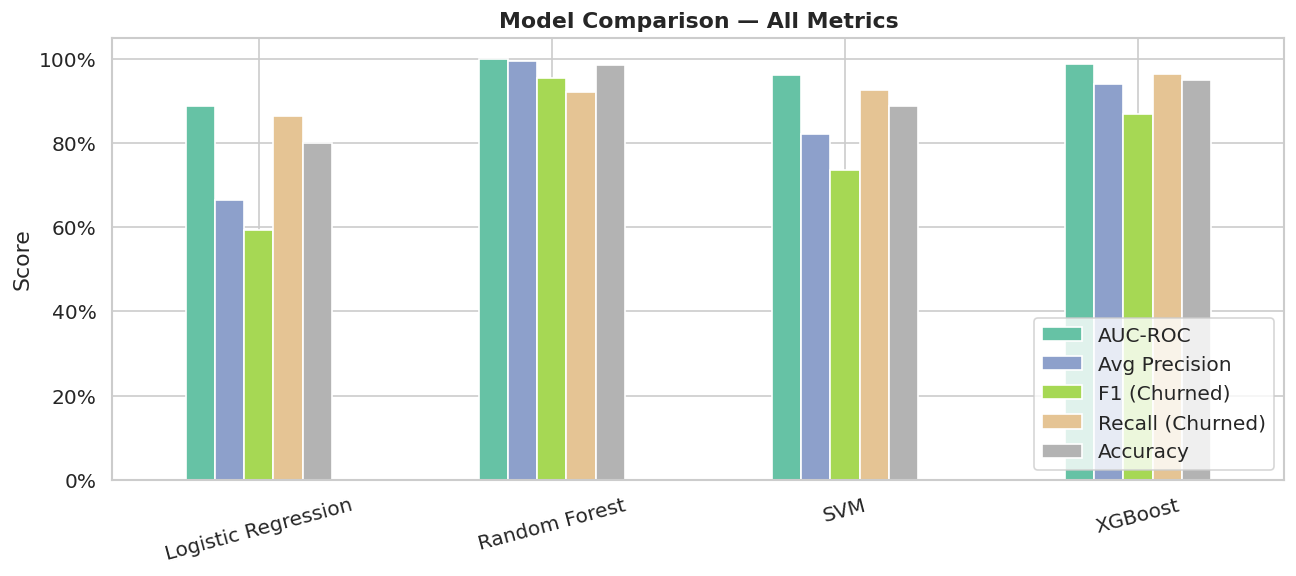


Model Comparison Table:
                     AUC-ROC  Avg Precision  F1 (Churned)  Recall (Churned)  Accuracy
Logistic Regression   0.8882         0.6639        0.5921            0.8632    0.7993
Random Forest         0.9989         0.9949        0.9537            0.9211    0.9849
SVM                   0.9602         0.8198        0.7364            0.9263    0.8881
XGBoost               0.9874         0.9408        0.8673            0.9632    0.9503


In [53]:
# ── Model comparison bar chart ────────────────────────────────────────────────
from sklearn.metrics import f1_score, accuracy_score, recall_score

comparison = pd.DataFrame({
    name: {
        'AUC-ROC':      res['AUC-ROC'],
        'Avg Precision': res['Avg Prec'],
        'F1 (Churned)': f1_score(y_test, res['y_pred']),
        'Recall (Churned)': recall_score(y_test, res['y_pred']),
        'Accuracy':     accuracy_score(y_test, res['y_pred'])
    }
    for name, res in results.items()
}).T

fig, ax = plt.subplots(figsize=(11, 5))
comparison.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='white', rot=15)
ax.set_ylabel('Score')
ax.set_title('Model Comparison — All Metrics', fontweight='bold')
ax.set_ylim(0, 1.05)
ax.legend(loc='lower right')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
plt.tight_layout()
plt.show()

print('\nModel Comparison Table:')
print(comparison.round(4).to_string())

## 8. Feature Importance & Business Insights

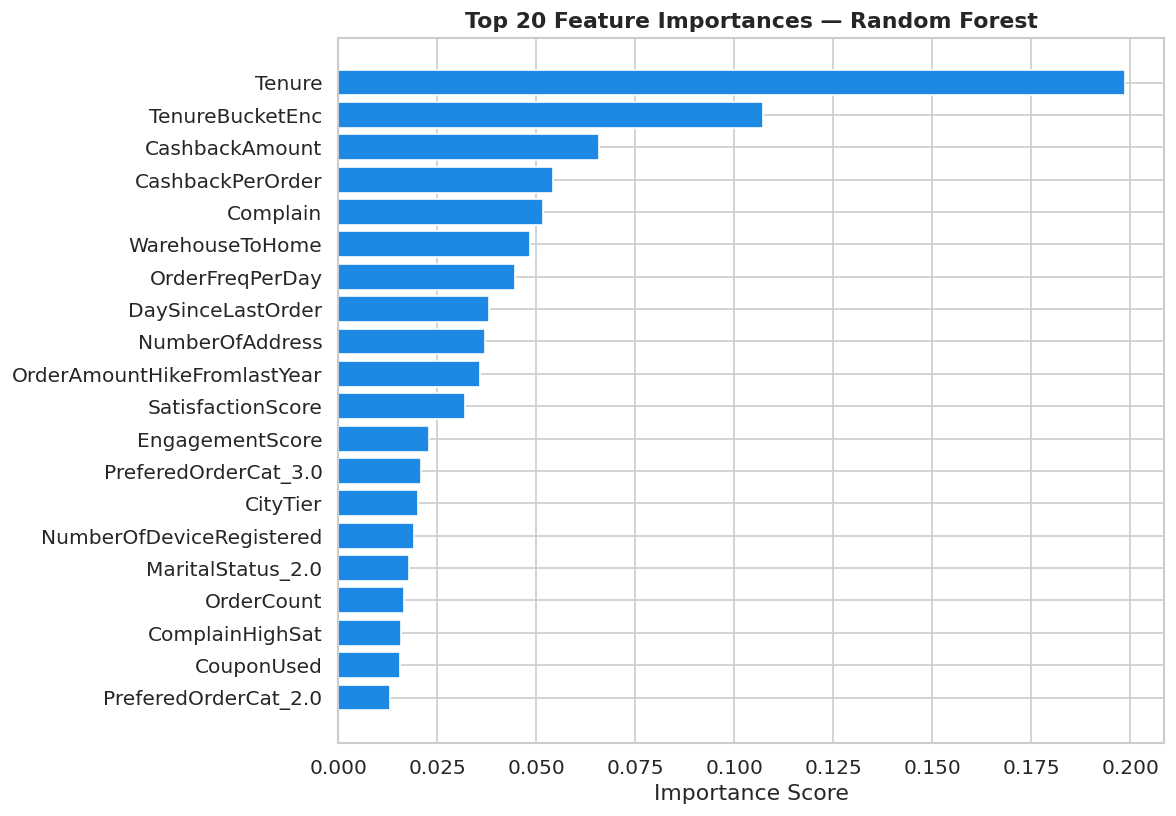

In [56]:
# ── Feature importance — Random Forest ───────────────────────────────────────
rf_model = trained_models['Random Forest']

fi_df = pd.DataFrame({
    'Feature':    feature_names,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(fi_df['Feature'][::-1], fi_df['Importance'][::-1], color='#1E88E5', edgecolor='white')
ax.set_xlabel('Importance Score')
ax.set_title('Top 20 Feature Importances — Random Forest', fontweight='bold')
plt.tight_layout()
plt.show()

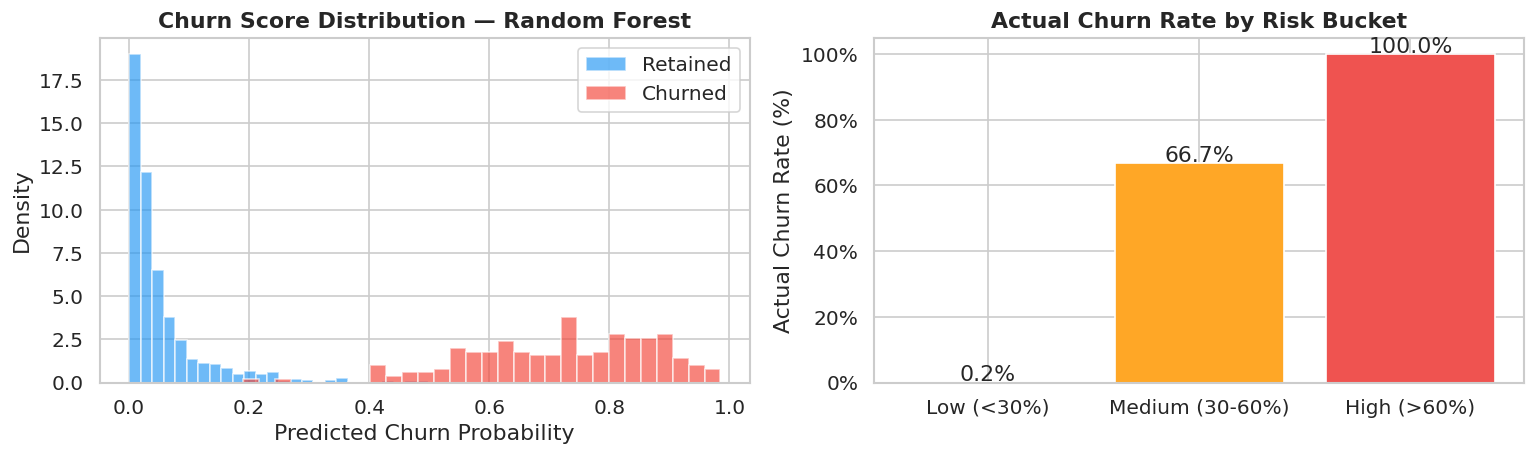

                 sum  count  churn_rate
risk                                   
Low (<30%)         2    838    0.238663
Medium (30-60%)   40     60   66.666667
High (>60%)      148    148  100.000000


In [55]:
# ── Churn probability distribution ───────────────────────────────────────────
best_proba = results[best_model_name]['y_proba']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram
for label, c in [(0, '#2196F3'), (1, '#F44336')]:
    mask = y_test == label
    axes[0].hist(best_proba[mask], bins=30, alpha=0.65,
                 label='Retained' if label == 0 else 'Churned', color=c, density=True)
axes[0].set_xlabel('Predicted Churn Probability')
axes[0].set_ylabel('Density')
axes[0].set_title(f'Churn Score Distribution — {best_model_name}', fontweight='bold')
axes[0].legend()

# Risk buckets
risk_df = pd.DataFrame({'proba': best_proba, 'actual': y_test.values})
risk_df['risk'] = pd.cut(risk_df['proba'], bins=[0, 0.3, 0.6, 1.0],
                          labels=['Low (<30%)', 'Medium (30-60%)', 'High (>60%)'])
risk_summary = risk_df.groupby('risk', observed=True)['actual'].agg(['sum', 'count'])
risk_summary['churn_rate'] = risk_summary['sum'] / risk_summary['count'] * 100

axes[1].bar(risk_summary.index, risk_summary['churn_rate'],
            color=['#66BB6A', '#FFA726', '#EF5350'], edgecolor='white')
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():.1f}%",
                     (p.get_x() + p.get_width()/2, p.get_height() + 0.5), ha='center')
axes[1].set_ylabel('Actual Churn Rate (%)')
axes[1].set_title('Actual Churn Rate by Risk Bucket', fontweight='bold')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())

plt.tight_layout()
plt.show()
print(risk_summary)

## Churn Score Distribution & Risk Bucketing — Random Forest

### Score Distribution
The model separates churners and retained customers **very cleanly**:
- Retained customers are overwhelmingly concentrated at scores **< 0.1**
- Churned customers spread broadly across **0.4 – 1.0** with no sharp peak,
  indicating the model captures churn risk as a spectrum rather than a binary flip

The minimal overlap between the two distributions is a strong sign of a
**well-calibrated, high-discrimination model**.

### Risk Bucket Validation
| Bucket | Customers | Actual Churn Rate |
|---|---|---|
| Low < 30% | 838 | 0.2% |
| Medium 30–60% | 60 | 66.7% |
| High > 60% | 148 | 100.0% |

The buckets are remarkably precise:
- **Every single customer the model flagged as High risk actually churned** — 100% precision
- **Low risk is essentially noise** — only 2 actual churners in 838 customers (0.2%)
- **Medium bucket is small (n=60)** but still captures two-thirds real churners

### Key Takeaways
- The model is **actionable immediately** — the High risk bucket requires zero
  tolerance for false positives, making targeted intervention both safe and efficient
- **148 high-risk customers** can be prioritized for CRM outreach with full confidence
- The tiny Medium bucket (60 customers) warrants investigation — lowering the
  High threshold to 50% would capture them with likely minimal false positive cost

### Business Recommendation
Deploy a **weekly scoring pipeline** with this exact bucketing:
- **High (>60%)** → immediate retention intervention (personalized offer, account manager call)
- **Medium (30–60%)** → soft engagement nudge (cashback boost, satisfaction check-in)
- **Low (<30%)** → no action needed, monitor passively

## 9. Conclusions & Business Recommendations

### Key Findings from EDA

| # | Finding | Implication |
|---|---------|-------------|
| 1 | **New customers (0-3 months) have the highest churn rate** | Invest in strong onboarding & early engagement programs |
| 2 | **Cash on Delivery users churn more** | Incentivise digital payments with cashback; improve CoD experience |
| 3 | **Mobile Phone buyers churn ~30%** | Category-specific loyalty programs & post-purchase support |
| 4 | **Complainers churn at ~2–3× the base rate** | Fast-track complaint resolution; proactive outreach |
| 5 | **Cashback lower for churners** | Personalised cashback offers for at-risk customers |
| 6 | **Single customers churn more than married** | Lifestyle-targeted promotions |
| 7 | **Satisfaction ≠ simple monotone of churn** — score 4 shows high churn | Go beyond satisfaction surveys; measure effort score |
